# 07 — Climatology and Seasonal Circulation
## จาก Monthly-Mean Archive สู่ January–July Climatology ของบรรยากาศที่ 850 hPa

**กลุ่มผู้เรียน:** นิสิตปริญญาตรีชั้นปีที่ 3–4 ด้านสิ่งแวดล้อม ภูมิศาสตร์ และภูมิสารสนเทศ  
**Platform:** Google Colab + Google Drive  
**ข้อมูลหลัก:** ERA5 Jan/Jul monthly-mean archive, 1981–2020  
**ระดับบรรยากาศ:** 850 hPa  
**บทก่อนหน้า:** Notebook 06 — Hovmöller and Spatiotemporal Analysis

Notebook นี้ตอบคำถามหลักว่า:

```text
monthly mean คืออะไร?
        ↓
climatology คืออะไร?
        ↓
ทำไมไฟล์ Jan/Jul 1981–2020 ยังไม่ใช่ climatology โดยตัวมันเอง?
        ↓
จะคำนวณ January climatology อย่างไร?
        ↓
จะคำนวณ July climatology อย่างไร?
        ↓
January และ July circulation ต่างกันอย่างไร?
        ↓
seasonal difference ต่างจาก anomaly อย่างไร?
```

> **Climatology คือสถิติที่คำนวณจากข้อมูลหลายปีสำหรับ calendar period เดียวกัน**

# Learning Objectives

เมื่อจบบทนี้ นิสิตควรสามารถ:

1. แยก monthly mean, climatology, seasonal difference และ anomaly
2. ตรวจว่า archive มีเฉพาะ January และ July
3. ตรวจช่วงปี 1981–2020 และจำนวนปี
4. คำนวณ January และ July climatology
5. แปลง temperature จาก K เป็น °C
6. แปลง geopotential เป็น geopotential height
7. คำนวณ wind speed จาก $u$ และ $v$
8. สร้าง January และ July climatological maps
9. สร้าง July − January seasonal-difference maps
10. เปรียบเทียบ RH และ relative vorticity
11. วิเคราะห์ interannual variability ของ regional means
12. อธิบายข้อจำกัดของ 850-hPa fields เหนือภูเขาสูง
13. export climatology, figures และ metadata

# 1. Monthly Mean

monthly mean ของตัวแปร $X$ ในเดือนหนึ่งของปีหนึ่งคือ:

$$
\overline{X}_{y,m}
=
\frac{1}{N}
\sum_{i=1}^{N}
X_i
$$

ใน teaching archive นี้แต่ละ time step เป็น monthly mean อยู่แล้ว

# 2. Climatology

January climatology ช่วง 1981–2020:

$$
\overline{X}_{Jan}
=
\frac{1}{N_y}
\sum_{y=1981}^{2020}
X_{y,Jan}
$$

July climatology:

$$
\overline{X}_{Jul}
=
\frac{1}{N_y}
\sum_{y=1981}^{2020}
X_{y,Jul}
$$

ดังนั้น:

```text
monthly-mean archive
→ input data

climatology
→ statistic computed across years
```

# 3. July − January Seasonal Difference

$$
\Delta X_{Jul-Jan}
=
\overline{X}_{Jul}
-
\overline{X}_{Jan}
$$

```text
ΔX > 0
→ July climatological value is higher

ΔX < 0
→ July climatological value is lower
```

นี่คือ seasonal contrast ไม่ใช่ anomaly

# 4. Seasonal Difference ≠ Anomaly

Anomaly ต้องเปรียบเทียบ event/observation กับ climatological baseline:

$$
X'
=
X
-
\overline{X}_{clim}
$$

แต่ Notebook 07 ใช้:

$$
\overline{X}_{Jul}
-
\overline{X}_{Jan}
$$

ดังนั้น:

```text
July − January
≠ anomaly
```

# 5. Climatology ≠ Trend

Climatology เป็น average state

Trend คือการเปลี่ยนแปลงตามเวลา เช่น:

$$
X(t)
=
a
+
bt
$$

Notebook นี้จะดู interannual variability แต่ยังไม่สรุป long-term trend

# 6. Latitude Weighting

บน regular latitude–longitude grid:

$$
A
\propto
\cos\phi
$$

regional mean จึงควรพิจารณา:

$$
\overline{X}
=
\frac{
\sum X\cos\phi
}{
\sum \cos\phi
}
$$

# 7. Geopotential Height

ERA5 `z` เป็น geopotential:

$$
Z
=
\frac{\Phi}{g_0}
$$

โดย:

$$
g_0
=
9.80665\ \mathrm{m\,s^{-2}}
$$

# 8. Wind Speed

$$
V
=
\sqrt{
u^2
+
v^2
}
$$

seasonal difference ของ wind speed และ seasonal vector difference ของ $u$/$v$ ไม่ใช่สิ่งเดียวกัน

# 9. 850-hPa Caveat เหนือภูเขาสูง

850 hPa อาจอยู่ต่ำกว่าพื้นดินเหนือ Tibetan Plateau และ Himalayas

teaching archive ไม่มี surface pressure สำหรับ below-ground mask ที่สมบูรณ์

> **ควรตีความ low-level fields เหนือ high terrain อย่างระมัดระวัง**

# 10. Archive Limitation

Archive นี้มีเฉพาะ:

```text
January
July
```

ช่วง:

```text
1981–2020
```

ดังนั้นไม่สามารถสร้าง October climatology จากไฟล์นี้ และไม่ควรใช้เพื่อคำนวณ October 2011 anomaly

# 11. ติดตั้งไลบรารี

In [1]:
# CELL 1 — Install/check libraries

import sys
import subprocess

PACKAGES = [
    "xarray>=2025.1",
    "netCDF4>=1.7",
    "h5netcdf>=1.4",
    "dask[array]>=2025.1",
    "numpy>=1.26",
    "pandas>=2.2",
    "matplotlib>=3.8",
    "cartopy>=0.23",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade-strategy",
        "only-if-needed",
        *PACKAGES,
    ]
)

print("Libraries ready.")

Libraries ready.


# 12. Mount Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path
from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False,
)

DRIVE_ROOT = Path(
    "/content/drive/MyDrive"
)

print("Google Drive mounted:", DRIVE_ROOT)

Mounted at /content/drive
Google Drive mounted: /content/drive/MyDrive


# 13. Import libraries

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from IPython.display import display

G0 = 9.80665

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("Xarray:", xr.__version__)

Python: 3.13.15
NumPy: 2.1.3
pandas: 2.2.3
Xarray: 2025.12.0


# 14. Course paths

In [4]:
# CELL 4 — Course paths

COURSE_ROOT = (
    DRIVE_ROOT
    / "Teaching_ERA5_Reanalysis_GIS"
)

SOURCE_GITHUB_DIR = (
    COURSE_ROOT
    / "00_source_github"
)

METADATA_DIR = (
    COURSE_ROOT
    / "02_metadata"
)

OUTPUT_DIR = (
    COURSE_ROOT
    / "03_output"
)

FIGURE_DIR = (
    COURSE_ROOT
    / "04_figures"
    / "07"
)

for folder in [
    METADATA_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

# ------------------------------------------------------------
# IMPORTANT:
# Notebook 00 downloads the monthly archive using this filename:
#
# era5_850hPa_JanJul_monthlymeans_1981_2020_Asia_0.5deg.nc
#
# The second name is retained only as a backward-compatible
# fallback for earlier versions of the preparation notebook.
# ------------------------------------------------------------

MONTHLY_BASELINE_CANDIDATES = [
    (
        SOURCE_GITHUB_DIR
        / "era5_850hPa_JanJul_monthlymeans_1981_2020_Asia_0.5deg.nc"
    ),
    (
        SOURCE_GITHUB_DIR
        / "era5_850hPa_JanJul_1981_2020_Asia_0.5deg.nc"
    ),
]

MONTHLY_BASELINE_FILE = next(
    (
        path
        for path in MONTHLY_BASELINE_CANDIDATES
        if path.exists()
    ),
    None,
)

if MONTHLY_BASELINE_FILE is None:
    available_nc_files = sorted(
        path.name
        for path in SOURCE_GITHUB_DIR.glob(
            "*.nc"
        )
    )

    raise FileNotFoundError(
        "Jan/Jul monthly-mean teaching archive was not found.\n\n"
        f"Expected folder:\n{SOURCE_GITHUB_DIR}\n\n"
        "Expected filename from Notebook 00:\n"
        "era5_850hPa_JanJul_monthlymeans_1981_2020_Asia_0.5deg.nc\n\n"
        f"NetCDF files currently found:\n{available_nc_files}\n\n"
        "Please run Notebook 00 if the file list is empty."
    )

print(
    "Monthly baseline archive:",
    MONTHLY_BASELINE_FILE,
)

print(
    "File size:",
    f"{MONTHLY_BASELINE_FILE.stat().st_size / 1024**2:.2f} MB",
)

Monthly baseline archive: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/00_source_github/era5_850hPa_JanJul_monthlymeans_1981_2020_Asia_0.5deg.nc
File size: 22.25 MB


# 15. เปิด Jan/Jul Monthly-Mean Archive

In [5]:
# CELL 5 — Open monthly-mean archive

ds = xr.open_dataset(
    MONTHLY_BASELINE_FILE,
    decode_times=True,
)

print(ds)

<xarray.Dataset> Size: 34MB
Dimensions:                    (time: 80, latitude: 110, longitude: 160)
Coordinates:
  * time                       (time) datetime64[ns] 640B 1981-01-01 ... 2020...
  * latitude                   (latitude) float32 440B 44.88 44.38 ... -9.625
  * longitude                  (longitude) float32 640B 60.12 60.62 ... 139.6
    source_pressure_level_hPa  float64 8B ...
Data variables:
    z                          (time, latitude, longitude) float32 6MB ...
    r                          (time, latitude, longitude) float32 6MB ...
    t                          (time, latitude, longitude) float32 6MB ...
    u                          (time, latitude, longitude) float32 6MB ...
    v                          (time, latitude, longitude) float32 6MB ...
    vo                         (time, latitude, longitude) float32 6MB ...
Attributes: (12/20)
    Conventions:                           CF-1.6
    history:                               2022-04-07 04:35:51 GMT 

# 16. ตรวจ Time Coverage, Months และ Variables

In [6]:
# CELL 6 — Archive audit

time_index = pd.DatetimeIndex(
    pd.to_datetime(
        ds["time"].values
    )
)

years_present = sorted(
    np.unique(
        time_index.year
    ).tolist()
)

months_present = sorted(
    np.unique(
        time_index.month
    ).tolist()
)

required_variables = [
    "z",
    "r",
    "t",
    "u",
    "v",
    "vo",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in ds.data_vars
]

ARCHIVE_AUDIT = pd.DataFrame(
    [
        {"item": "time_start", "value": str(time_index.min())},
        {"item": "time_end", "value": str(time_index.max())},
        {"item": "n_time_steps", "value": int(ds.sizes["time"])},
        {"item": "n_years", "value": len(years_present)},
        {"item": "year_start", "value": min(years_present)},
        {"item": "year_end", "value": max(years_present)},
        {"item": "months_present", "value": str(months_present)},
        {"item": "variables", "value": ",".join(ds.data_vars)},
    ]
)

display(ARCHIVE_AUDIT)

if missing_variables:
    raise KeyError(
        f"Missing variables: {missing_variables}"
    )

if months_present != [1, 7]:
    raise ValueError(
        f"Expected January and July only, found {months_present}"
    )

print("Confirmed: archive contains January and July only.")

,item,value
0,time_start,1981-01-01 00:00:00
1,time_end,2020-07-01 00:00:00
2,n_time_steps,80
3,n_years,40
4,year_start,1981
5,year_end,2020
6,months_present,"[1, 7]"
7,variables,"z,r,t,u,v,vo"


Confirmed: archive contains January and July only.


# 17. ตรวจ 850-hPa Metadata

In [7]:
# CELL 7 — Pressure-level metadata audit

pressure_metadata_rows = []

if "pressure_level" in ds.coords:
    pressure_metadata_rows.append(
        {
            "source": "scalar coordinate",
            "value_hPa": float(
                ds["pressure_level"].values
            ),
        }
    )

for key in [
    "pressure_level_hPa",
    "declared_pressure_level_hPa",
    "source_pressure_level_hPa",
]:
    if key in ds.attrs:
        pressure_metadata_rows.append(
            {
                "source": f"global attribute: {key}",
                "value_hPa": ds.attrs[key],
            }
        )

if not pressure_metadata_rows:
    pressure_metadata_rows.append(
        {
            "source": "teaching-course declared metadata",
            "value_hPa": 850.0,
        }
    )

PRESSURE_METADATA = pd.DataFrame(
    pressure_metadata_rows
)

display(PRESSURE_METADATA)

,source,value_hPa
0,teaching-course declared metadata,850.0


Source เดิมไม่มี pressure dimension ดังนั้น 850 hPa ในชุดนี้เป็น source/preparation metadata ไม่ใช่ dimension ที่ใช้ `.sel(level=850)` ได้เหมือน EVENT dataset

# 18. Spatial Helper Functions

In [8]:
# CELL 8 — Coordinate-aware subsetting

def coordinate_slice(
    coordinate,
    lower,
    upper,
):
    values = np.asarray(
        coordinate.values
    )

    if values[-1] > values[0]:
        return slice(
            lower,
            upper,
        )

    return slice(
        upper,
        lower,
    )


def subset_domain(
    data_array,
    domain,
):
    subset = data_array.sel(
        latitude=coordinate_slice(
            data_array["latitude"],
            domain["lat_min"],
            domain["lat_max"],
        ),
        longitude=coordinate_slice(
            data_array["longitude"],
            domain["lon_min"],
            domain["lon_max"],
        ),
    )

    if (
        subset.sizes["latitude"] == 0
        or subset.sizes["longitude"] == 0
    ):
        raise ValueError(
            "Spatial subset is empty."
        )

    return subset

In [9]:
# CELL 9 — Map decoration helper

def decorate_map(
    ax,
    *,
    domain,
):
    ax.coastlines(
        resolution="110m",
        linewidth=0.7,
    )

    ax.add_feature(
        cfeature.BORDERS,
        linewidth=0.5,
    )

    ax.set_extent(
        [
            domain["lon_min"],
            domain["lon_max"],
            domain["lat_min"],
            domain["lat_max"],
        ],
        crs=ccrs.PlateCarree(),
    )

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.35,
        alpha=0.45,
        linestyle="--",
    )

    gl.top_labels = False
    gl.right_labels = False

    return ax

# 19. Derived-Variable Helper Functions

In [10]:
# CELL 10 — Derived variables

def temperature_celsius(
    temperature_K,
):
    result = temperature_K - 273.15
    result.name = "temperature_C"
    result.attrs.update(
        {
            "long_name": "Air temperature",
            "units": "degC",
        }
    )
    return result


def geopotential_height(
    geopotential,
):
    result = geopotential / G0
    result.name = "geopotential_height"
    result.attrs.update(
        {
            "long_name": "Geopotential height",
            "units": "m",
        }
    )
    return result


def wind_speed(
    u,
    v,
):
    result = np.hypot(
        u,
        v,
    )
    result.name = "wind_speed"
    result.attrs.update(
        {
            "long_name": "Wind speed",
            "units": "m s-1",
        }
    )
    return result

# 20. กำหนด Analysis Domains

In [11]:
# CELL 11 — Analysis domains

SE_ASIA_DOMAIN = {
    "lon_min": 80.0,
    "lon_max": 130.0,
    "lat_min": 0.0,
    "lat_max": 35.0,
}

THAILAND_BOX = {
    "lon_min": 97.0,
    "lon_max": 106.0,
    "lat_min": 5.0,
    "lat_max": 21.0,
}

print(
    "Southeast Asia domain:",
    SE_ASIA_DOMAIN,
)

Southeast Asia domain: {'lon_min': 80.0, 'lon_max': 130.0, 'lat_min': 0.0, 'lat_max': 35.0}


# 21. คำนวณ January และ July Climatology

In [12]:
# CELL 12 — Compute January and July climatologies

january_archive = ds.sel(
    time=(
        ds["time"].dt.month
        == 1
    )
)

july_archive = ds.sel(
    time=(
        ds["time"].dt.month
        == 7
    )
)

JAN_CLIM = january_archive.mean(
    dim="time",
    keep_attrs=True,
)

JUL_CLIM = july_archive.mean(
    dim="time",
    keep_attrs=True,
)

print(
    "January years:",
    january_archive.sizes["time"],
)

print(
    "July years:",
    july_archive.sizes["time"],
)

print(
    "Climatologies computed."
)

January years: 40
July years: 40
Climatologies computed.


# 22. สร้าง Derived Climatological Fields

In [13]:
# CELL 13 — Derived climatological fields

JAN_T_C = temperature_celsius(
    JAN_CLIM["t"]
)

JUL_T_C = temperature_celsius(
    JUL_CLIM["t"]
)

JAN_Z_M = geopotential_height(
    JAN_CLIM["z"]
)

JUL_Z_M = geopotential_height(
    JUL_CLIM["z"]
)

JAN_WIND_SPEED = wind_speed(
    JAN_CLIM["u"],
    JAN_CLIM["v"],
)

JUL_WIND_SPEED = wind_speed(
    JUL_CLIM["u"],
    JUL_CLIM["v"],
)

JAN_RH = JAN_CLIM["r"]
JUL_RH = JUL_CLIM["r"]

JAN_VORT = JAN_CLIM["vo"]
JUL_VORT = JUL_CLIM["vo"]

print(
    "Derived climatological fields ready."
)

Derived climatological fields ready.


# 23. Figure 07-1 — Monthly-Mean Archive Domain

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


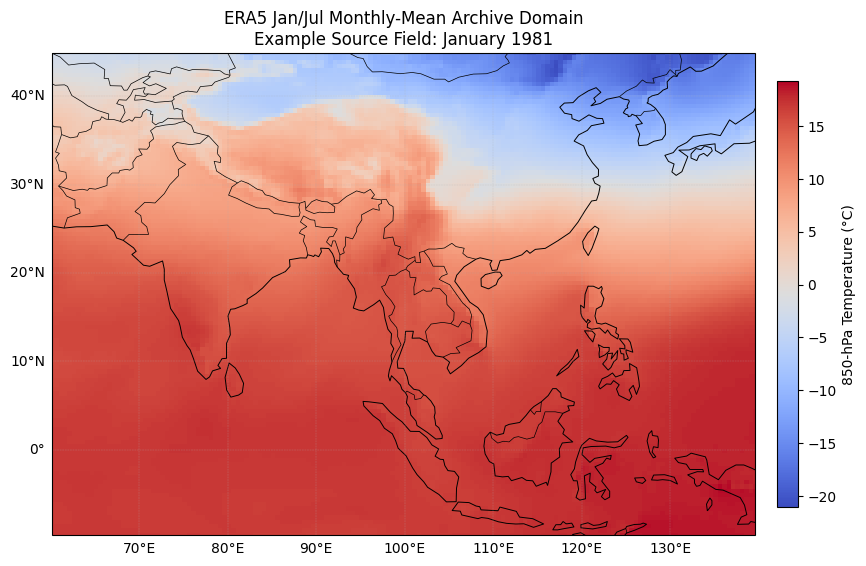

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/07/07_01_monthly_archive_domain.png


In [14]:
# CELL 14 — Archive domain map

sample_field = temperature_celsius(
    ds["t"].isel(
        time=0
    )
)

fig = plt.figure(
    figsize=(11, 6.5)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    sample_field["longitude"],
    sample_field["latitude"],
    sample_field,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="coolwarm",
)

ax.coastlines(
    resolution="110m",
    linewidth=0.7,
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.5,
)

ax.set_extent(
    [
        float(sample_field["longitude"].min()),
        float(sample_field["longitude"].max()),
        float(sample_field["latitude"].min()),
        float(sample_field["latitude"].max()),
    ],
    crs=ccrs.PlateCarree(),
)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.35,
    alpha=0.45,
    linestyle="--",
)

gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "850-hPa Temperature (°C)"
)

actual_time = pd.Timestamp(
    sample_field["time"].values
)

ax.set_title(
    "ERA5 Jan/Jul Monthly-Mean Archive Domain\n"
    f"Example Source Field: {actual_time:%B %Y}"
)

FIG_07_01 = (
    FIGURE_DIR
    / "07_01_monthly_archive_domain.png"
)

plt.savefig(
    FIG_07_01,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_07_01,
)

# 24. Figure 07-2 — January 850-hPa Climatological Circulation

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


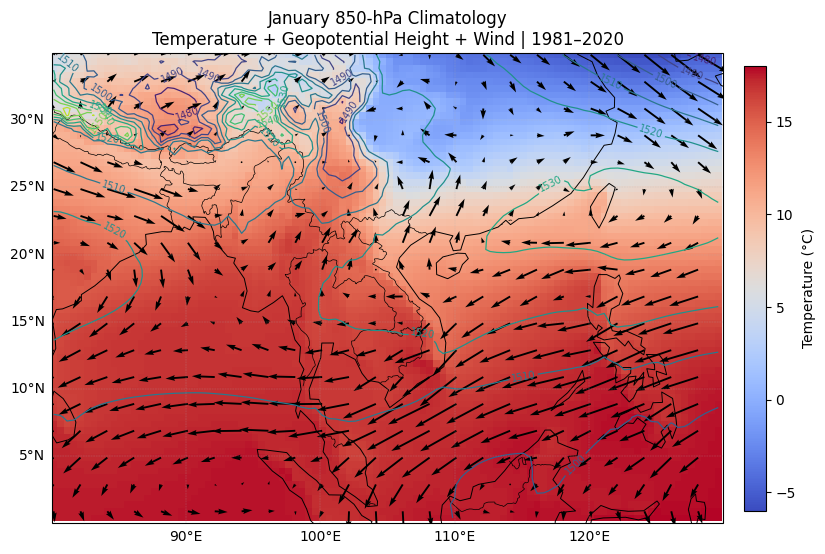

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/07/07_02_january_850hPa_climatology.png


In [15]:
# CELL 15 — January climatology map

jan_t = subset_domain(
    JAN_T_C,
    SE_ASIA_DOMAIN,
)

jan_z = subset_domain(
    JAN_Z_M,
    SE_ASIA_DOMAIN,
)

jan_u = subset_domain(
    JAN_CLIM["u"],
    SE_ASIA_DOMAIN,
)

jan_v = subset_domain(
    JAN_CLIM["v"],
    SE_ASIA_DOMAIN,
)

fig = plt.figure(
    figsize=(10.5, 6.8)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    jan_t["longitude"],
    jan_t["latitude"],
    jan_t,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="coolwarm",
)

contours = ax.contour(
    jan_z["longitude"],
    jan_z["latitude"],
    jan_z,
    levels=10,
    transform=ccrs.PlateCarree(),
    linewidths=0.9,
)

ax.clabel(
    contours,
    inline=True,
    fontsize=7,
    fmt="%.0f",
)

skip = 4

ax.quiver(
    jan_u["longitude"].values[::skip],
    jan_u["latitude"].values[::skip],
    jan_u.values[::skip, ::skip],
    jan_v.values[::skip, ::skip],
    transform=ccrs.PlateCarree(),
)

decorate_map(
    ax,
    domain=SE_ASIA_DOMAIN,
)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "Temperature (°C)"
)

ax.set_title(
    "January 850-hPa Climatology\n"
    "Temperature + Geopotential Height + Wind | 1981–2020"
)

FIG_07_02 = (
    FIGURE_DIR
    / "07_02_january_850hPa_climatology.png"
)

plt.savefig(
    FIG_07_02,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_07_02,
)

# 25. Figure 07-3 — July 850-hPa Climatological Circulation

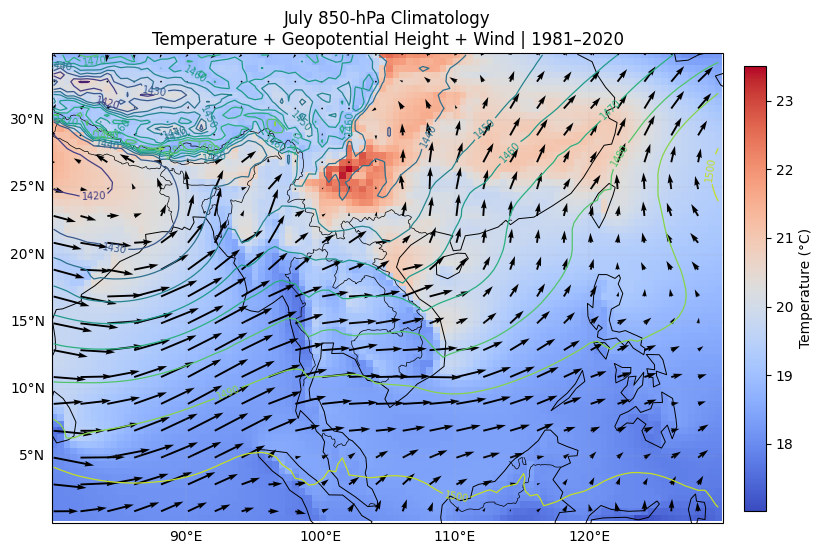

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/07/07_03_july_850hPa_climatology.png


In [16]:
# CELL 16 — July climatology map

jul_t = subset_domain(
    JUL_T_C,
    SE_ASIA_DOMAIN,
)

jul_z = subset_domain(
    JUL_Z_M,
    SE_ASIA_DOMAIN,
)

jul_u = subset_domain(
    JUL_CLIM["u"],
    SE_ASIA_DOMAIN,
)

jul_v = subset_domain(
    JUL_CLIM["v"],
    SE_ASIA_DOMAIN,
)

fig = plt.figure(
    figsize=(10.5, 6.8)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    jul_t["longitude"],
    jul_t["latitude"],
    jul_t,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="coolwarm",
)

contours = ax.contour(
    jul_z["longitude"],
    jul_z["latitude"],
    jul_z,
    levels=10,
    transform=ccrs.PlateCarree(),
    linewidths=0.9,
)

ax.clabel(
    contours,
    inline=True,
    fontsize=7,
    fmt="%.0f",
)

skip = 4

ax.quiver(
    jul_u["longitude"].values[::skip],
    jul_u["latitude"].values[::skip],
    jul_u.values[::skip, ::skip],
    jul_v.values[::skip, ::skip],
    transform=ccrs.PlateCarree(),
)

decorate_map(
    ax,
    domain=SE_ASIA_DOMAIN,
)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "Temperature (°C)"
)

ax.set_title(
    "July 850-hPa Climatology\n"
    "Temperature + Geopotential Height + Wind | 1981–2020"
)

FIG_07_03 = (
    FIGURE_DIR
    / "07_03_july_850hPa_climatology.png"
)

plt.savefig(
    FIG_07_03,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_07_03,
)

# 26. การเปรียบเทียบ January และ July

ให้พิจารณา:

```text
temperature pattern
geopotential-height pattern
wind direction
wind magnitude
regional gradients
```

ใช้คำว่า **climatological circulation** และ **seasonal contrast** ไม่ใช่ event, anomaly หรือ trend

# 27. คำนวณ July − January Seasonal Differences

In [17]:
# CELL 17 — Seasonal differences

DELTA_T = (
    JUL_T_C
    - JAN_T_C
)

DELTA_Z = (
    JUL_Z_M
    - JAN_Z_M
)

DELTA_RH = (
    JUL_RH
    - JAN_RH
)

DELTA_U = (
    JUL_CLIM["u"]
    - JAN_CLIM["u"]
)

DELTA_V = (
    JUL_CLIM["v"]
    - JAN_CLIM["v"]
)

DELTA_VORT = (
    JUL_VORT
    - JAN_VORT
)

DELTA_WIND_VECTOR_MAG = np.hypot(
    DELTA_U,
    DELTA_V,
)

DELTA_WIND_VECTOR_MAG.name = (
    "seasonal_wind_vector_difference"
)

print(
    "July − January seasonal differences ready."
)

July − January seasonal differences ready.


# 28. Figure 07-4 — July − January Temperature and Wind-Vector Difference

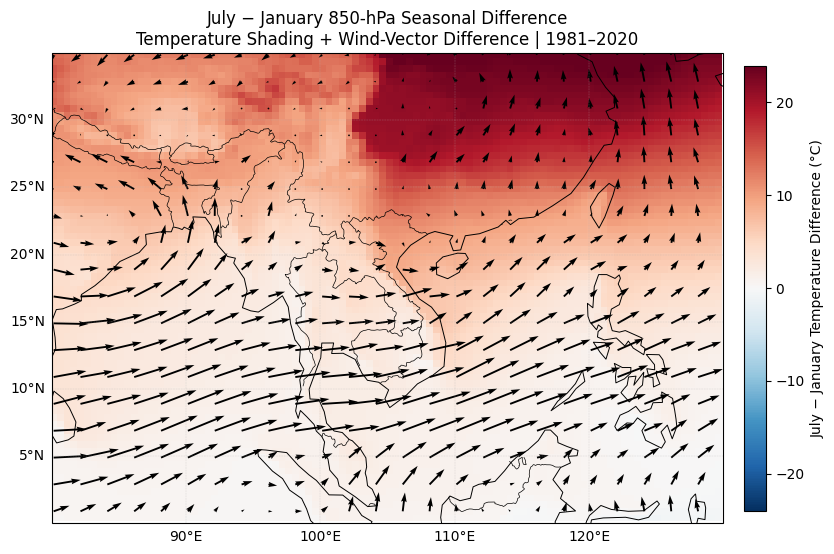

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/07/07_04_july_minus_january_temperature_wind_difference.png


In [18]:
# CELL 18 — Seasonal difference map

delta_t = subset_domain(
    DELTA_T,
    SE_ASIA_DOMAIN,
)

delta_u = subset_domain(
    DELTA_U,
    SE_ASIA_DOMAIN,
)

delta_v = subset_domain(
    DELTA_V,
    SE_ASIA_DOMAIN,
)

temp_abs = float(
    np.nanpercentile(
        np.abs(
            delta_t.values
        ),
        99,
    )
)

temp_abs = max(
    temp_abs,
    1.0,
)

norm = TwoSlopeNorm(
    vmin=-temp_abs,
    vcenter=0.0,
    vmax=temp_abs,
)

fig = plt.figure(
    figsize=(10.5, 6.8)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

mesh = ax.pcolormesh(
    delta_t["longitude"],
    delta_t["latitude"],
    delta_t,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="RdBu_r",
    norm=norm,
)

skip = 4

ax.quiver(
    delta_u["longitude"].values[::skip],
    delta_u["latitude"].values[::skip],
    delta_u.values[::skip, ::skip],
    delta_v.values[::skip, ::skip],
    transform=ccrs.PlateCarree(),
)

decorate_map(
    ax,
    domain=SE_ASIA_DOMAIN,
)

cbar = plt.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.85,
)

cbar.set_label(
    "July − January Temperature Difference (°C)"
)

ax.set_title(
    "July − January 850-hPa Seasonal Difference\n"
    "Temperature Shading + Wind-Vector Difference | 1981–2020"
)

FIG_07_04 = (
    FIGURE_DIR
    / "07_04_july_minus_january_temperature_wind_difference.png"
)

plt.savefig(
    FIG_07_04,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_07_04,
)

# 29. Figure 07-5 — Seasonal Difference of RH and Relative Vorticity

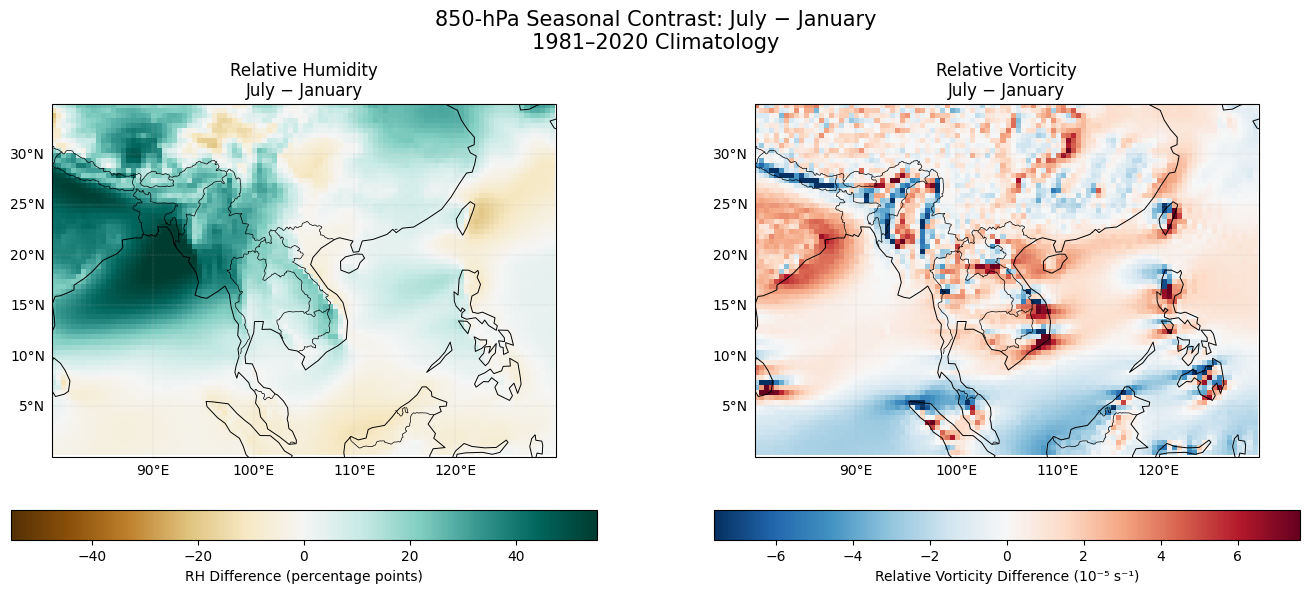

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/07/07_05_july_minus_january_RH_vorticity_difference.png


In [19]:
# CELL 19 — RH and vorticity seasonal differences

delta_rh = subset_domain(
    DELTA_RH,
    SE_ASIA_DOMAIN,
)

delta_vort_scaled = (
    subset_domain(
        DELTA_VORT,
        SE_ASIA_DOMAIN,
    )
    * 1.0e5
)

rh_abs = float(
    np.nanpercentile(
        np.abs(
            delta_rh.values
        ),
        99,
    )
)

rh_abs = max(
    rh_abs,
    1.0,
)

vort_abs = float(
    np.nanpercentile(
        np.abs(
            delta_vort_scaled.values
        ),
        99,
    )
)

vort_abs = max(
    vort_abs,
    1.0,
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5.8),
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    constrained_layout=True,
)

mesh_rh = axes[0].pcolormesh(
    delta_rh["longitude"],
    delta_rh["latitude"],
    delta_rh,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="BrBG",
    norm=TwoSlopeNorm(
        vmin=-rh_abs,
        vcenter=0.0,
        vmax=rh_abs,
    ),
)

decorate_map(
    axes[0],
    domain=SE_ASIA_DOMAIN,
)

axes[0].set_title(
    "Relative Humidity\nJuly − January"
)

mesh_vort = axes[1].pcolormesh(
    delta_vort_scaled["longitude"],
    delta_vort_scaled["latitude"],
    delta_vort_scaled,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="RdBu_r",
    norm=TwoSlopeNorm(
        vmin=-vort_abs,
        vcenter=0.0,
        vmax=vort_abs,
    ),
)

decorate_map(
    axes[1],
    domain=SE_ASIA_DOMAIN,
)

axes[1].set_title(
    "Relative Vorticity\nJuly − January"
)

cbar_rh = fig.colorbar(
    mesh_rh,
    ax=axes[0],
    orientation="horizontal",
    pad=0.08,
    shrink=0.85,
)

cbar_rh.set_label(
    "RH Difference (percentage points)"
)

cbar_vort = fig.colorbar(
    mesh_vort,
    ax=axes[1],
    orientation="horizontal",
    pad=0.08,
    shrink=0.85,
)

cbar_vort.set_label(
    "Relative Vorticity Difference (10⁻⁵ s⁻¹)"
)

fig.suptitle(
    "850-hPa Seasonal Contrast: July − January\n"
    "1981–2020 Climatology",
    fontsize=15,
)

FIG_07_05 = (
    FIGURE_DIR
    / "07_05_july_minus_january_RH_vorticity_difference.png"
)

plt.savefig(
    FIG_07_05,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_07_05,
)

# 30. Regional Mean และ Interannual Variability

Climatology เป็นค่าเฉลี่ยหลายปี แต่แต่ละปียังมี variability

เราจะใช้ Thailand box:

```text
97–106°E
5–21°N
```

แล้วคำนวณ latitude-weighted regional mean

> **climatological mean ไม่ได้หมายความว่าทุกปีเหมือนกัน**

In [20]:
# CELL 20 — Latitude-weighted regional mean helper

def weighted_regional_mean(
    data_array,
    domain,
):
    subset = subset_domain(
        data_array,
        domain,
    )

    weights = np.cos(
        np.deg2rad(
            subset["latitude"]
        )
    )

    return (
        subset
        .weighted(
            weights
        )
        .mean(
            dim=(
                "latitude",
                "longitude",
            )
        )
    )

In [21]:
# CELL 21 — Interannual regional means

regional_t_C = temperature_celsius(
    ds["t"]
)

regional_series = pd.DataFrame(
    {
        "time": pd.to_datetime(
            ds["time"].values
        ),
        "temperature_C": weighted_regional_mean(
            regional_t_C,
            THAILAND_BOX,
        ).values,
        "relative_humidity_pct": weighted_regional_mean(
            ds["r"],
            THAILAND_BOX,
        ).values,
        "u_ms": weighted_regional_mean(
            ds["u"],
            THAILAND_BOX,
        ).values,
        "v_ms": weighted_regional_mean(
            ds["v"],
            THAILAND_BOX,
        ).values,
    }
)

regional_series[
    "year"
] = regional_series[
    "time"
].dt.year

regional_series[
    "month"
] = regional_series[
    "time"
].dt.month

regional_series[
    "month_name"
] = regional_series[
    "month"
].map(
    {
        1: "January",
        7: "July",
    }
)

display(
    regional_series.head(
        8
    )
)

,time,temperature_C,relative_humidity_pct,u_ms,v_ms,year,month,month_name
0,1981-01-01,14.959861,68.165764,-2.906673,-0.802925,1981,1,January
1,1981-07-01,18.766031,79.475372,7.110755,1.632356,1981,7,July
2,1982-01-01,15.198785,68.453751,-2.769608,-0.875435,1982,1,January
3,1982-07-01,18.563299,80.121078,8.201088,1.775970,1982,7,July
4,1983-01-01,15.529881,70.119698,-3.413280,0.518277,1983,1,January
5,1983-07-01,19.024879,80.805389,5.368519,1.843083,1983,7,July
6,1984-01-01,15.475374,73.710106,-3.105867,-0.248946,1984,1,January
7,1984-07-01,18.385794,79.745125,5.041757,1.761485,1984,7,July


# 31. Figure 07-6 — Thailand-Box Interannual Variability

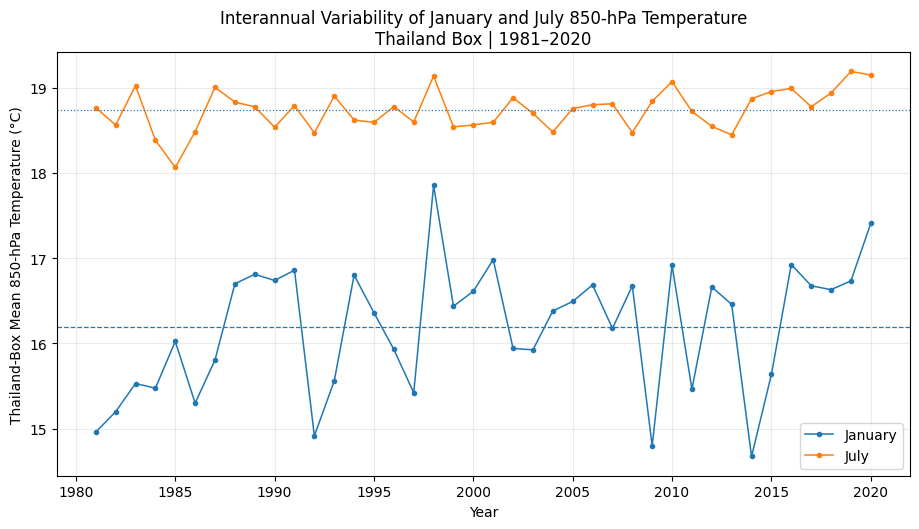

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/04_figures/07/07_06_thailand_interannual_temperature_variability.png


In [22]:
# CELL 22 — Interannual temperature variability

fig, ax = plt.subplots(
    figsize=(11, 5.5)
)

for month_name, group in (
    regional_series.groupby(
        "month_name"
    )
):
    group = group.sort_values(
        "year"
    )

    ax.plot(
        group["year"],
        group["temperature_C"],
        marker="o",
        markersize=3,
        linewidth=1.1,
        label=month_name,
    )

jan_mean = float(
    regional_series.loc[
        regional_series[
            "month"
        ]
        == 1,
        "temperature_C",
    ].mean()
)

jul_mean = float(
    regional_series.loc[
        regional_series[
            "month"
        ]
        == 7,
        "temperature_C",
    ].mean()
)

ax.axhline(
    jan_mean,
    linewidth=0.9,
    linestyle="--",
)

ax.axhline(
    jul_mean,
    linewidth=0.9,
    linestyle=":",
)

ax.set_xlabel(
    "Year"
)

ax.set_ylabel(
    "Thailand-Box Mean 850-hPa Temperature (°C)"
)

ax.set_title(
    "Interannual Variability of January and July 850-hPa Temperature\n"
    "Thailand Box | 1981–2020"
)

ax.grid(
    True,
    alpha=0.25,
)

ax.legend()

FIG_07_06 = (
    FIGURE_DIR
    / "07_06_thailand_interannual_temperature_variability.png"
)

plt.savefig(
    FIG_07_06,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    FIG_07_06,
)

# 32. Figure 07-6 ไม่ใช่ Trend Analysis

ยังไม่ได้ fit regression, ทดสอบ statistical significance หรือประเมิน autocorrelation

ดังนั้นเป้าหมายคือดู **interannual variability** ไม่ใช่สรุป climate trend

# 33. Thailand-Box Climatological Summary

In [23]:
# CELL 23 — Thailand-box climatological summary

summary_rows = []

for month_value, month_name in [
    (1, "January"),
    (7, "July"),
]:
    group = regional_series.loc[
        regional_series[
            "month"
        ]
        == month_value
    ]

    summary_rows.append(
        {
            "month": month_name,
            "n_years": int(
                len(
                    group
                )
            ),
            "temperature_mean_C": float(
                group[
                    "temperature_C"
                ].mean()
            ),
            "temperature_std_C": float(
                group[
                    "temperature_C"
                ].std(
                    ddof=1
                )
            ),
            "RH_mean_pct": float(
                group[
                    "relative_humidity_pct"
                ].mean()
            ),
            "u_mean_ms": float(
                group[
                    "u_ms"
                ].mean()
            ),
            "v_mean_ms": float(
                group[
                    "v_ms"
                ].mean()
            ),
        }
    )

THAILAND_CLIM_SUMMARY = pd.DataFrame(
    summary_rows
)

display(
    THAILAND_CLIM_SUMMARY
)

,month,n_years,temperature_mean_C,temperature_std_C,RH_mean_pct,u_mean_ms,v_mean_ms
0,January,40,16.188656,0.749747,70.025536,-3.277799,-0.112859
1,July,40,18.736744,0.239737,79.930931,7.025566,1.417990


# 34. Observation–Interpretation–Limitation Framework

In [24]:
# CELL 24 — Interpretation framework

INTERPRETATION_TEMPLATE = pd.DataFrame(
    [
        {
            "diagnostic": "January climatology",
            "observation": (
                "Describe mean 850-hPa temperature, height and wind pattern."
            ),
            "interpretation": (
                "Interpret lower-tropospheric January circulation."
            ),
            "limitation": (
                "A climatological mean smooths interannual and synoptic variability."
            ),
        },
        {
            "diagnostic": "July climatology",
            "observation": (
                "Describe mean 850-hPa temperature, height and wind pattern."
            ),
            "interpretation": (
                "Interpret lower-tropospheric July circulation."
            ),
            "limitation": (
                "Mean circulation does not represent every July."
            ),
        },
        {
            "diagnostic": "July minus January",
            "observation": (
                "Describe where climatological fields are higher or lower in July."
            ),
            "interpretation": (
                "Interpret seasonal contrast."
            ),
            "limitation": (
                "This is not an anomaly from a climatological baseline."
            ),
        },
    ]
)

display(
    INTERPRETATION_TEMPLATE
)

,diagnostic,observation,interpretation,limitation
0,January climatology,"Describe mean 850-hPa temperature, height and ...",Interpret lower-tropospheric January circulation.,A climatological mean smooths interannual and ...
1,July climatology,"Describe mean 850-hPa temperature, height and ...",Interpret lower-tropospheric July circulation.,Mean circulation does not represent every July.
2,July minus January,Describe where climatological fields are highe...,Interpret seasonal contrast.,This is not an anomaly from a climatological b...


# 35. Export Climatology and Seasonal-Difference Products

In [25]:
# CELL 25 — Export derived NetCDF and tables

CLIMATOLOGY_NETCDF = (
    OUTPUT_DIR
    / "07_JanJul_1981_2020_850hPa_climatology.nc"
)

REGIONAL_SERIES_CSV = (
    OUTPUT_DIR
    / "07_thailand_box_JanJul_interannual_series.csv"
)

CLIM_SUMMARY_CSV = (
    OUTPUT_DIR
    / "07_thailand_box_climatological_summary.csv"
)

INTERPRETATION_TEMPLATE_CSV = (
    OUTPUT_DIR
    / "07_climatology_interpretation_template.csv"
)

CLIM_METADATA_CSV = (
    METADATA_DIR
    / "07_climatology_analysis_metadata.csv"
)

derived_clim = xr.Dataset(
    {
        "temperature_C_January": JAN_T_C,
        "temperature_C_July": JUL_T_C,
        "temperature_C_Jul_minus_Jan": DELTA_T,
        "geopotential_height_m_January": JAN_Z_M,
        "geopotential_height_m_July": JUL_Z_M,
        "relative_humidity_January": JAN_RH,
        "relative_humidity_July": JUL_RH,
        "relative_humidity_Jul_minus_Jan": DELTA_RH,
        "u_January": JAN_CLIM["u"],
        "u_July": JUL_CLIM["u"],
        "v_January": JAN_CLIM["v"],
        "v_July": JUL_CLIM["v"],
        "relative_vorticity_January": JAN_VORT,
        "relative_vorticity_July": JUL_VORT,
    }
)

derived_clim.attrs.update(
    {
        "course": (
            "Teaching ERA5 Reanalysis and GIS"
        ),
        "notebook": (
            "07 Climatology and Seasonal Circulation"
        ),
        "baseline_period": "1981-2020",
        "months": "January and July only",
        "pressure_level_hPa": 850.0,
        "important_note": (
            "July minus January is a seasonal difference, not an anomaly."
        ),
        "october_limitation": (
            "This archive contains no October climatology."
        ),
    }
)

encoding = {
    variable_name: {
        "zlib": True,
        "complevel": 4,
        "shuffle": True,
        "dtype": "float32",
    }
    for variable_name
    in derived_clim.data_vars
}

derived_clim.to_netcdf(
    CLIMATOLOGY_NETCDF,
    engine="netcdf4",
    encoding=encoding,
)

regional_series.to_csv(
    REGIONAL_SERIES_CSV,
    index=False,
)

THAILAND_CLIM_SUMMARY.to_csv(
    CLIM_SUMMARY_CSV,
    index=False,
)

INTERPRETATION_TEMPLATE.to_csv(
    INTERPRETATION_TEMPLATE_CSV,
    index=False,
)

CLIM_METADATA = pd.DataFrame(
    [
        {
            "parameter": "source_file",
            "value": MONTHLY_BASELINE_FILE.name,
        },
        {
            "parameter": "source_semantics",
            "value": (
                "Monthly-mean archive; climatology computed in Notebook 07"
            ),
        },
        {
            "parameter": "baseline_period",
            "value": "1981–2020",
        },
        {
            "parameter": "months_available",
            "value": "January, July",
        },
        {
            "parameter": "pressure_level_hPa",
            "value": 850,
        },
        {
            "parameter": "seasonal_difference_definition",
            "value": (
                "July climatology minus January climatology"
            ),
        },
        {
            "parameter": "anomaly_warning",
            "value": (
                "July-January difference is not a climatological anomaly"
            ),
        },
        {
            "parameter": "october_warning",
            "value": (
                "No October climatology is available in this archive"
            ),
        },
        {
            "parameter": "terrain_warning",
            "value": (
                "850 hPa may be below ground over high terrain"
            ),
        },
    ]
)

CLIM_METADATA.to_csv(
    CLIM_METADATA_CSV,
    index=False,
)

print(
    "Saved:",
    CLIMATOLOGY_NETCDF,
)

print(
    "Saved:",
    REGIONAL_SERIES_CSV,
)

print(
    "Saved:",
    CLIM_METADATA_CSV,
)

Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/07_JanJul_1981_2020_850hPa_climatology.nc
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/03_output/07_thailand_box_JanJul_interannual_series.csv
Saved: /content/drive/MyDrive/Teaching_ERA5_Reanalysis_GIS/02_metadata/07_climatology_analysis_metadata.csv


# 36. Figure Manifest

In [26]:
# CELL 26 — Figure manifest

FIGURE_MANIFEST = pd.DataFrame(
    [
        {
            "figure": "07-01",
            "file": str(FIG_07_01),
            "description": "Jan/Jul monthly-mean archive domain",
        },
        {
            "figure": "07-02",
            "file": str(FIG_07_02),
            "description": "January 850-hPa climatological circulation",
        },
        {
            "figure": "07-03",
            "file": str(FIG_07_03),
            "description": "July 850-hPa climatological circulation",
        },
        {
            "figure": "07-04",
            "file": str(FIG_07_04),
            "description": (
                "July minus January temperature and wind-vector difference"
            ),
        },
        {
            "figure": "07-05",
            "file": str(FIG_07_05),
            "description": (
                "July minus January RH and relative-vorticity difference"
            ),
        },
        {
            "figure": "07-06",
            "file": str(FIG_07_06),
            "description": (
                "Thailand-box January and July interannual temperature variability"
            ),
        },
    ]
)

FIGURE_MANIFEST_CSV = (
    METADATA_DIR
    / "07_figure_manifest.csv"
)

FIGURE_MANIFEST.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False,
)

display(
    FIGURE_MANIFEST
)

,figure,file,description
0,07-01,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Jan/Jul monthly-mean archive domain
1,07-02,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,January 850-hPa climatological circulation
2,07-03,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,July 850-hPa climatological circulation
3,07-04,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,July minus January temperature and wind-vector...
4,07-05,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,July minus January RH and relative-vorticity d...
5,07-06,/content/drive/MyDrive/Teaching_ERA5_Reanalysi...,Thailand-box January and July interannual temp...


# 37. Common Mistakes

### Mistake 1
เรียก source archive ว่า climatology ทั้งที่ยังไม่ได้ average across years

### Mistake 2
เรียก July − January ว่า anomaly

### Mistake 3
เรียก interannual variability plot ว่า trend โดยไม่ทำ trend analysis

### Mistake 4
คิดว่า climatological mean แทนทุก January หรือ July

### Mistake 5
ละเลย latitude weighting ใน regional mean

### Mistake 6
เรียก ERA5 `z` ว่า metres โดยไม่หารด้วย $g_0$

### Mistake 7
ตีความ 850-hPa fields เหนือ Tibetan Plateau โดยไม่คำนึงถึง below-ground pressure surface

### Mistake 8
ใช้ archive นี้คำนวณ October climatology ทั้งที่ไม่มี October

# 38. Exercises

### Exercise 1 — Climatology Definition

อธิบายความแตกต่างระหว่าง:

```text
monthly mean
climatology
seasonal difference
anomaly
```

### Exercise 2 — January vs July

จาก Figures 07-2 และ 07-3 ให้เขียน:

```text
Observation
Interpretation
Limitation
```

สำหรับทั้งสองเดือน

### Exercise 3 — Seasonal Temperature Difference

เลือกประเทศไทย อินเดีย หรือทะเลจีนใต้ แล้วอธิบาย sign ของ:

$$
\overline{T}_{Jul}
-
\overline{T}_{Jan}
$$

### Exercise 4 — Wind Difference

อธิบายว่าทำไม:

```text
vector difference
≠ difference in wind speed only
```

### Exercise 5 — Moisture

เปรียบเทียบ July − January RH

### Exercise 6 — Interannual Variability

เลือก January หรือ July แล้วคำนวณ mean, standard deviation, minimum และ maximum ของ Thailand-box temperature

### Exercise 7 — Archive Limitation

ตอบว่า:

> ทำไมเราไม่ควรใช้ไฟล์นี้คำนวณ October 2011 temperature anomaly?

# 39. Final Readiness Check

In [27]:
# CELL 27 — Final readiness

readiness_rows = []


def add_check(
    item,
    passed,
    note="",
):
    readiness_rows.append(
        {
            "item": item,
            "status": (
                "PASS"
                if passed
                else "FAIL"
            ),
            "note": note,
        }
    )


add_check(
    "Monthly archive opened",
    isinstance(
        ds,
        xr.Dataset,
    ),
)

add_check(
    "January and July only confirmed",
    months_present == [
        1,
        7,
    ],
)

add_check(
    "1981–2020 period available",
    (
        min(
            years_present
        )
        == 1981
        and max(
            years_present
        )
        == 2020
    ),
)

add_check(
    "January climatology created",
    isinstance(
        JAN_CLIM,
        xr.Dataset,
    ),
)

add_check(
    "July climatology created",
    isinstance(
        JUL_CLIM,
        xr.Dataset,
    ),
)

for figure_path, label in [
    (
        FIG_07_01,
        "Archive-domain figure",
    ),
    (
        FIG_07_02,
        "January climatology figure",
    ),
    (
        FIG_07_03,
        "July climatology figure",
    ),
    (
        FIG_07_04,
        "Temperature/wind seasonal-difference figure",
    ),
    (
        FIG_07_05,
        "RH/vorticity seasonal-difference figure",
    ),
    (
        FIG_07_06,
        "Interannual-variability figure",
    ),
]:
    add_check(
        f"{label} exported",
        figure_path.exists(),
    )

add_check(
    "Derived climatology NetCDF exported",
    CLIMATOLOGY_NETCDF.exists(),
)

add_check(
    "Regional series CSV exported",
    REGIONAL_SERIES_CSV.exists(),
)

add_check(
    "Climatology metadata exported",
    CLIM_METADATA_CSV.exists(),
)

READINESS = pd.DataFrame(
    readiness_rows
)

display(
    READINESS
)

ALL_READY = bool(
    (
        READINESS[
            "status"
        ]
        == "PASS"
    ).all()
)

READINESS_CSV = (
    METADATA_DIR
    / "07_readiness_check.csv"
)

READINESS.to_csv(
    READINESS_CSV,
    index=False,
)

print()

if ALL_READY:
    print(
        "NOTEBOOK 07 READY"
    )

    print(
        "Next: Notebook 08 — Anomaly Concepts and Baseline Matching"
    )

else:
    print(
        "NOTEBOOK 07 REQUIRES REVIEW"
    )

,item,status,note
0,Monthly archive opened,PASS,
1,January and July only confirmed,PASS,
2,1981–2020 period available,PASS,
3,January climatology created,PASS,
4,July climatology created,PASS,
5,Archive-domain figure exported,PASS,
6,January climatology figure exported,PASS,
7,July climatology figure exported,PASS,
8,Temperature/wind seasonal-difference figure ex...,PASS,
9,RH/vorticity seasonal-difference figure exported,PASS,



NOTEBOOK 07 READY
Next: Notebook 08 — Anomaly Concepts and Baseline Matching


# 40. สิ่งที่ต้องจำจาก Notebook 07

```text
monthly mean
→ average within one month of one year

climatology
→ average of same calendar month across many years

January archive
→ input monthly means

January climatology
→ mean of January 1981–2020

July − January
→ seasonal difference

seasonal difference
≠ anomaly

climatology
≠ trend

interannual variability
≠ trend automatically

850 hPa over high terrain
→ interpret cautiously

Jan/Jul archive
→ cannot provide October climatology
```

> **Climatology เป็น baseline statistic ที่ต้องสร้างอย่างถูกต้องก่อนจะพูดถึง anomaly**

# Course Progress

```text
00  Download & Data Audit              ✓
 ↓
01  NetCDF & Xarray Fundamentals       ✓
 ↓
02  Spatial Subsetting & Cartopy       ✓
 ↓
03  Pressure-Level Structure           ✓
 ↓
04  Wind & Vector Analysis             ✓
 ↓
05  Synoptic Maps & Dynamics           ✓
 ↓
06  Hovmöller & Spatiotemporal         ✓
 ↓
07  Climatology & Seasonal Circulation ✓
 ↓
08  Anomaly Concepts & Baseline Matching
 ↓
09  Integrated Noul 2011 Case Study
```